In [1]:
import os
print(os.getcwd())
print(os.listdir())


C:\Users\Thejas\DocTrace_AI\ml-training
['.gitkeep', '.ipynb_checkpoints', '01-phash-experiments.ipynb', 'img1.jpg', 'img2.jpg', 'img3.jpg', 'requirements.txt', 'sample.pdf', 'Untitled.ipynb']


In [2]:
import pdfplumber

pdf = pdfplumber.open("sample.pdf")
page = pdf.pages[0]

print("Page size:", page.width, "x", page.height)
words = page.extract_words()
print("Words found:", len(words))
print()
print(words[0])

Page size: 595 x 842
Words found: 40

{'text': 'BHAT', 'x0': 191.94, 'x1': 247.48, 'top': 50.139999999999986, 'doctop': 50.139999999999986, 'bottom': 70.13999999999999, 'upright': True, 'height': 20.0, 'width': 55.53999999999999, 'direction': 'ltr'}


In [3]:
for w in words[:10]:
    print(f"{w['text']:20s}  x0={w['x0']:.0f}  top={w['top']:.0f}")

BHAT                  x0=192  top=50
&                     x0=253  top=50
ASSOCIATES            x0=273  top=50
Chartered             x0=231  top=74
Accountants           x0=291  top=74
Invoice               x0=36  top=110
Number                x0=74  top=110
:                     x0=116  top=110
INV-0001              x0=122  top=110
Invoice               x0=36  top=126


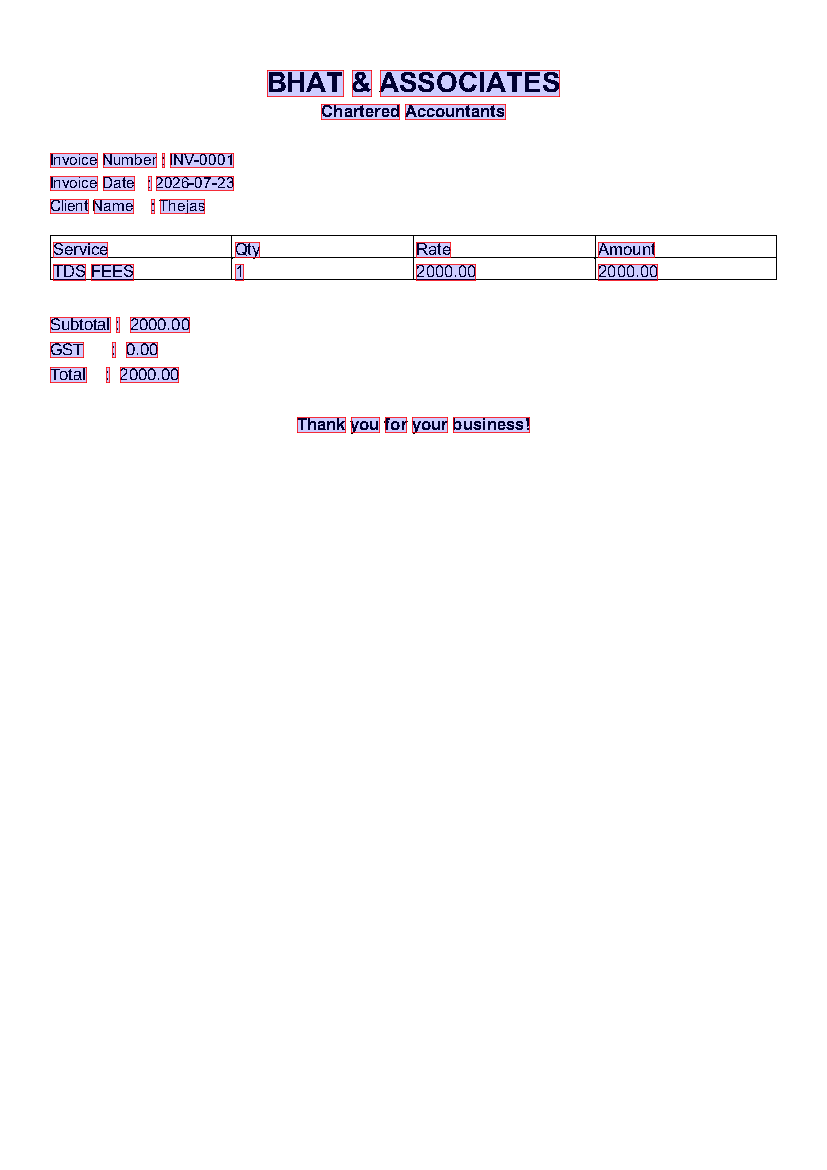

In [4]:
im = page.to_image(resolution=100)
im.draw_rects(words)
im

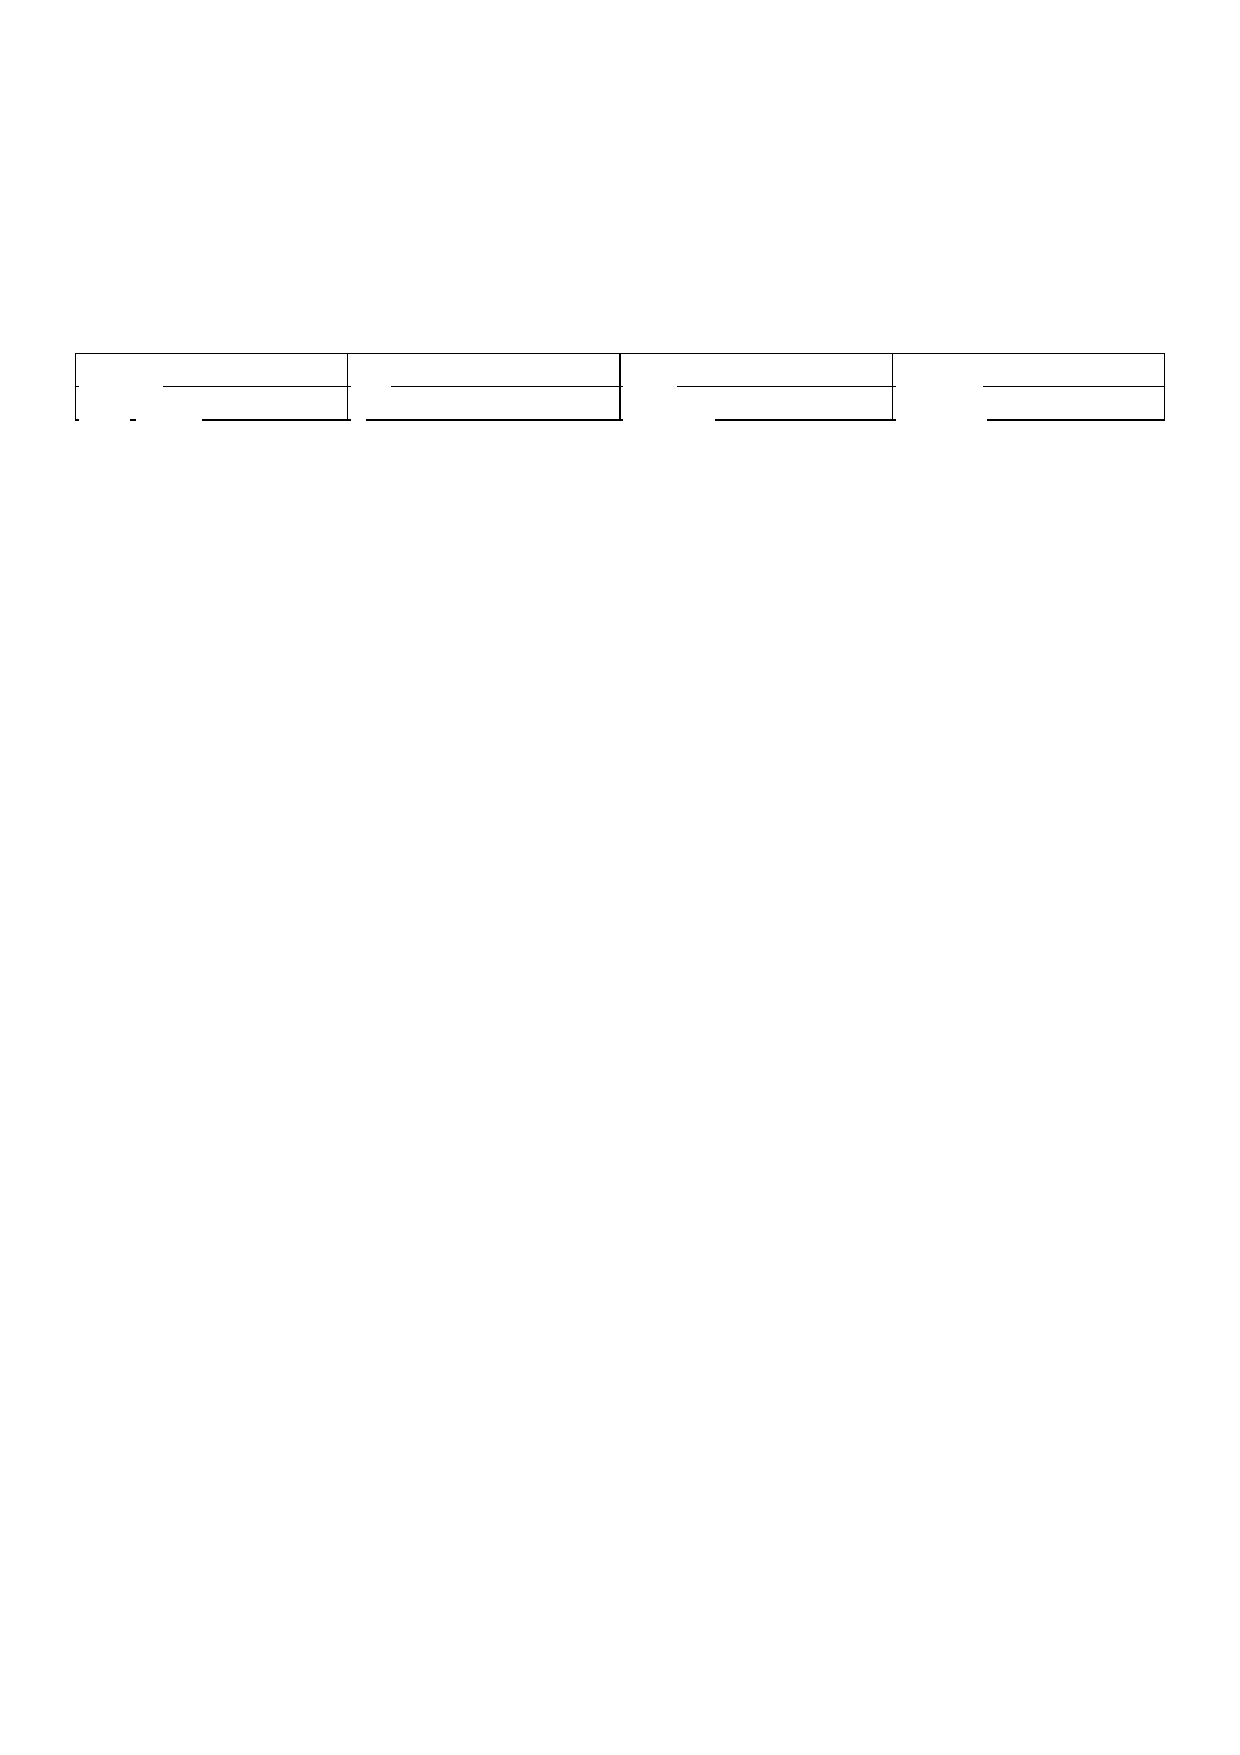

In [5]:
from PIL import Image, ImageDraw

# render page at higher resolution
scale = 150 / 72          # points → pixels at 150 DPI
im2 = page.to_image(resolution=150)
pil = im2.original.copy()  # the underlying PIL image
draw = ImageDraw.Draw(pil)

for w in words:
    draw.rectangle(
        [w['x0']*scale, w['top']*scale, w['x1']*scale, w['bottom']*scale],
        fill="white"
    )

pil